# Day 14: Project 1 — XGBoost/LightGBM Tuning

**Dataset:** diabetes_clean.csv (from Day 12)
**Target:** `readmitted_binary` (11.2% positive)
**Baseline:** Logistic Regression ROC-AUC=0.652
**Goal:** Train & tune XGBoost & LightGBM, SHAP explainability

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score, classification_report,
                             roc_curve, precision_recall_curve, f1_score)
import xgboost as xgb
import lightgbm as lgb
import shap
import joblib

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

# Load cleaned data
df = pd.read_csv('data/diabetes_clean.csv')
print(f"Loaded: {df.shape}")

Loaded: (101766, 57)


In [3]:
# 1. PREPARE DATA (same split as Day 13)
exclude_cols = ['encounter_id', 'patient_nbr', 'diag_1', 'diag_2', 'diag_3', 
                'readmitted', 'readmitted_binary']
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols]
y = df['readmitted_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Preprocessor (fit on train)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Train processed: {X_train_processed.shape}")
print(f"Test processed: {X_test_processed.shape}")

Train processed: (81412, 268)
Test processed: (20354, 268)


In [4]:
# 2. XGBOOST (default params)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_clf.fit(X_train_processed, y_train)

y_proba_xgb = xgb_clf.predict_proba(X_test_processed)[:, 1]
y_pred_xgb = xgb_clf.predict(X_test_processed)

xgb_roc = roc_auc_score(y_test, y_proba_xgb)
xgb_pr = average_precision_score(y_test, y_proba_xgb)

print("=== XGBoost (default) ===")
print(f"ROC-AUC: {xgb_roc:.4f}")
print(f"PR-AUC:  {xgb_pr:.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=['No Readmit', 'Readmit <30']))

scale_pos_weight: 7.96
=== XGBoost (default) ===
ROC-AUC: 0.6859
PR-AUC:  0.2389
              precision    recall  f1-score   support

  No Readmit       0.93      0.67      0.78     18083
 Readmit <30       0.18      0.59      0.28      2271

    accuracy                           0.66     20354
   macro avg       0.56      0.63      0.53     20354
weighted avg       0.85      0.66      0.72     20354



In [5]:
# 3. LIGHTGBM (default params)
lgb_clf = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=42,
    verbose=-1,
    n_jobs=-1
)
lgb_clf.fit(X_train_processed, y_train)

y_proba_lgb = lgb_clf.predict_proba(X_test_processed)[:, 1]
y_pred_lgb = lgb_clf.predict(X_test_processed)

lgb_roc = roc_auc_score(y_test, y_proba_lgb)
lgb_pr = average_precision_score(y_test, y_proba_lgb)

print("=== LightGBM (default) ===")
print(f"ROC-AUC: {lgb_roc:.4f}")
print(f"PR-AUC:  {lgb_pr:.4f}")
print(classification_report(y_test, y_pred_lgb, target_names=['No Readmit', 'Readmit <30']))

c:\Users\Bakrim\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Bakrim\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== LightGBM (default) ===
ROC-AUC: 0.6870
PR-AUC:  0.2380
              precision    recall  f1-score   support

  No Readmit       0.93      0.67      0.78     18083
 Readmit <30       0.18      0.59      0.28      2271

    accuracy                           0.66     20354
   macro avg       0.56      0.63      0.53     20354
weighted avg       0.85      0.66      0.72     20354



In [6]:
# 4. HYPERPARAMETER TUNING: XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_xgb = GridSearchCV(
    xgb_base, param_grid_xgb, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_xgb.fit(X_train_processed, y_train)

print(f"Best XGBoost params: {grid_xgb.best_params_}")
print(f"Best XGBoost CV ROC-AUC: {grid_xgb.best_score_:.4f}")

best_xgb = grid_xgb.best_estimator_
y_proba_best_xgb = best_xgb.predict_proba(X_test_processed)[:, 1]
y_pred_best_xgb = best_xgb.predict(X_test_processed)

best_xgb_roc = roc_auc_score(y_test, y_proba_best_xgb)
best_xgb_pr = average_precision_score(y_test, y_proba_best_xgb)

print(f"\nTest ROC-AUC: {best_xgb_roc:.4f}")
print(f"Test PR-AUC:  {best_xgb_pr:.4f}")
print(classification_report(y_test, y_pred_best_xgb, target_names=['No Readmit', 'Readmit <30']))

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best XGBoost params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best XGBoost CV ROC-AUC: 0.6737

Test ROC-AUC: 0.6888
Test PR-AUC:  0.2380
              precision    recall  f1-score   support

  No Readmit       0.93      0.66      0.77     18083
 Readmit <30       0.19      0.61      0.28      2271

    accuracy                           0.66     20354
   macro avg       0.56      0.64      0.53     20354
weighted avg       0.85      0.66      0.72     20354



In [7]:
# 5. HYPERPARAMETER TUNING: LightGBM
param_grid_lgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'num_leaves': [15, 31, 63],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

lgb_base = lgb.LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

grid_lgb = GridSearchCV(
    lgb_base, param_grid_lgb, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_lgb.fit(X_train_processed, y_train)

print(f"Best LightGBM params: {grid_lgb.best_params_}")
print(f"Best LightGBM CV ROC-AUC: {grid_lgb.best_score_:.4f}")

best_lgb = grid_lgb.best_estimator_
y_proba_best_lgb = best_lgb.predict_proba(X_test_processed)[:, 1]
y_pred_best_lgb = best_lgb.predict(X_test_processed)

best_lgb_roc = roc_auc_score(y_test, y_proba_best_lgb)
best_lgb_pr = average_precision_score(y_test, y_proba_best_lgb)

print(f"\nTest ROC-AUC: {best_lgb_roc:.4f}")
print(f"Test PR-AUC:  {best_lgb_pr:.4f}")
print(classification_report(y_test, y_pred_best_lgb, target_names=['No Readmit', 'Readmit <30']))

Fitting 3 folds for each of 324 candidates, totalling 972 fits
Best LightGBM params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}
Best LightGBM CV ROC-AUC: 0.6740

Test ROC-AUC: 0.6894
Test PR-AUC:  0.2375
              precision    recall  f1-score   support

  No Readmit       0.93      0.66      0.77     18083
 Readmit <30       0.18      0.61      0.28      2271

    accuracy                           0.66     20354
   macro avg       0.56      0.64      0.53     20354
weighted avg       0.85      0.66      0.72     20354



c:\Users\Bakrim\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Bakrim\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [8]:
# 6. MODEL COMPARISON
print("=== Model Comparison ===")
print(f"Logistic Regression: ROC-AUC=0.6518, PR-AUC=0.2050")
print(f"XGBoost (default):   ROC-AUC={xgb_roc:.4f}, PR-AUC={xgb_pr:.4f}")
print(f"LightGBM (default):  ROC-AUC={lgb_roc:.4f}, PR-AUC={lgb_pr:.4f}")
print(f"XGBoost (tuned):     ROC-AUC={best_xgb_roc:.4f}, PR-AUC={best_xgb_pr:.4f}")
print(f"LightGBM (tuned):    ROC-AUC={best_lgb_roc:.4f}, PR-AUC={best_lgb_pr:.4f}")

=== Model Comparison ===
Logistic Regression: ROC-AUC=0.6518, PR-AUC=0.2050
XGBoost (default):   ROC-AUC=0.6859, PR-AUC=0.2389
LightGBM (default):  ROC-AUC=0.6870, PR-AUC=0.2380
XGBoost (tuned):     ROC-AUC=0.6888, PR-AUC=0.2380
LightGBM (tuned):    ROC-AUC=0.6894, PR-AUC=0.2375



=== SHAP Analysis: LightGBM ===


c:\Users\Bakrim\anaconda3\envs\myenv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


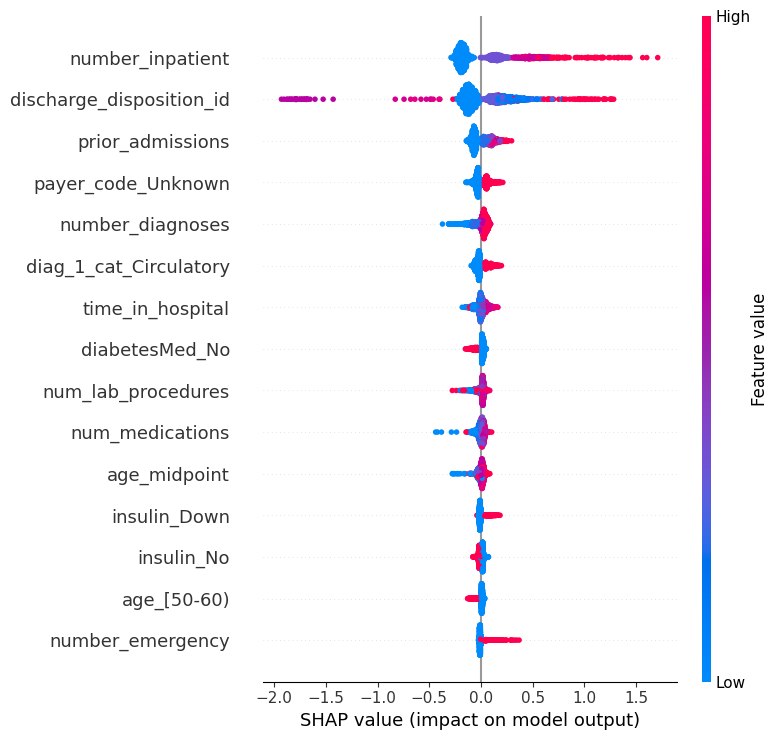

In [9]:
# 7. SHAP EXPLAINABILITY (best model)
best_model = best_xgb if best_xgb_roc >= best_lgb_roc else best_lgb
best_name = "XGBoost" if best_xgb_roc >= best_lgb_roc else "LightGBM"

print(f"\n=== SHAP Analysis: {best_name} ===")

# Sample for SHAP (large dataset = slow)
sample_size = min(2000, len(X_train_processed))
sample_idx = np.random.choice(len(X_train_processed), sample_size, replace=False)
X_shap = X_train_processed[sample_idx]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

# Feature names
cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features)
all_feature_names = list(numeric_features) + list(cat_feature_names)

# Summary plot
shap.summary_plot(shap_values, X_shap, feature_names=all_feature_names, max_display=15, show=False)
plt.tight_layout()
plt.show()

In [10]:
# 8. SAVE BEST PIPELINE
import os
os.makedirs('../models', exist_ok=True)

# Full pipeline with preprocessor + best model
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])

model_path = 'models/readmission_best.joblib'
joblib.dump(best_pipeline, model_path)

print(f"Best pipeline ({best_name}) saved to {model_path}")

Best pipeline (LightGBM) saved to models/readmission_best.joblib
